# 04 — Regression (Linear & Logistic)

"Regression" does double duty. *Linear regression* predicts a **number**
(price, count, temperature). *Logistic regression* predicts a **probability
of a class** despite the name. They share a linear core, so we treat them
together — and we end with the trap that ruins more regression conclusions
than any other: **the hidden confounder** (§3.2–3.3).

## What you'll be able to do after this notebook

1. Fit and — more importantly — **read** simple and multiple linear regression.
2. Diagnose a model with four plots, not four numbers (residuals, fitted-vs-actual,
 coefficient bars, Q–Q).
3. Use **regularisation** (Ridge/Lasso) deliberately to fight overfitting.
4. Fit **logistic regression** and evaluate it with ROC/AUC + calibration.
5. **Interpret coefficients honestly**, including spotting when a confounder
 has flipped your conclusion (Simpson's paradox, §3.3).
6. Avoid the four classic regression self‑inflicted wounds (§7 pitfalls).

## The process, in one diagram

```mermaid
flowchart TD
 E["EDA: who's related to whom?<br/><small> §2 correlation</small>"] --> S
 S["Split — hold out the test set, never look"] --> F
 F["Fit on train, diagnose with residual plots<br/><small> §6 bias/variance</small>"] --> R
 R["Regularise / simplify if overfitting"] --> I
 I["Interpret coefficients<br/> check for confounding first — §3"] --> T
 T["Final score on the untouched test set"]
```

## 1. The idea, in plain language

### Linear regression
Draw the **best straight line** (or hyperplane) through your points. "Best"
means it minimises the sum of squared vertical distances — the **residuals**.

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

Each $\beta_j$ says: *holding the other features fixed*, how much does $y$
change when $x_j$ goes up by one unit. That "holding other features fixed" is
doing a lot of work — it's exactly where confounding (§3) sneaks in.

### Logistic regression
Same linear core, but the output is squashed through the **sigmoid** so it
becomes a probability in (0, 1):

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p)}}$$

Predict "class 1" when $p \ge 0.5$ — or any threshold that fits your cost of
false positives vs false negatives (§5 on Type I/II errors). That $p$ is a
**probability** in the Bayesian sense (degree of belief); **notebook 04½** unpacks
what that means, including why a high $p$ on a rare class still implies a low
posterior (base‑rate neglect, the disease‑screening paradox).

> **Vocabulary note (§8):** "error" here means a *residual* ($y - \hat y$),
> not a classification mistake. Same word, different meaning — context decides.

## 2. Setup

We use **Ames Housing** (1,460 homes, 80 features) for the linear side — it's
the modern replacement for the retired Boston dataset and has the kind of
relationships that make regression interesting. We'll bring the **CEO data**
back for logistic regression, and a synthetic confounder example at the end.

In [1]:
from setup import *
from scipy import stats

ames = fetch_openml(name="house_prices", version=1, as_frame=True, parser="auto").frame
ames = ames.drop(columns=["Id"])
y_log = np.log1p(ames["SalePrice"]) # log target — see notebook 03 / §1.3 skewness
print("Ames shape:", ames.shape)

Ames shape: (1460, 80)


## 3. Start with EDA — *always* look before you fit

Two questions matter most before any regression:

1. **How is each candidate predictor related to the target?** (§2 — correlation
 is a *linear* measure only.)
2. **How are the predictors related to *each other*?** (§7.2 — multicollinearity
 destabilises coefficients.)

Skipping this is the #1 cause of uninterpretable models.

In [2]:
# Pick a compact, interpretable feature set and look at it.
feats = ["GrLivArea", "OverallQual", "GarageCars", "TotalBsmtSF",
 "YearBuilt", "TotRmsAbvGrd", "GarageArea"]
corr_with_target = (ames[feats + ["SalePrice"]]
 .assign(SalePrice_log=y_log)
 .corr(numeric_only=True)["SalePrice_log"]
 .drop("SalePrice_log").sort_values(key=abs, ascending=False))
corr_with_target.round(3).to_frame("Pearson r vs log(SalePrice)")

,Pearson r vs log(SalePrice)
SalePrice,0.948
OverallQual,0.817
GrLivArea,0.701
GarageCars,0.681
GarageArea,0.651
TotalBsmtSF,0.612
YearBuilt,0.587
TotRmsAbvGrd,0.534


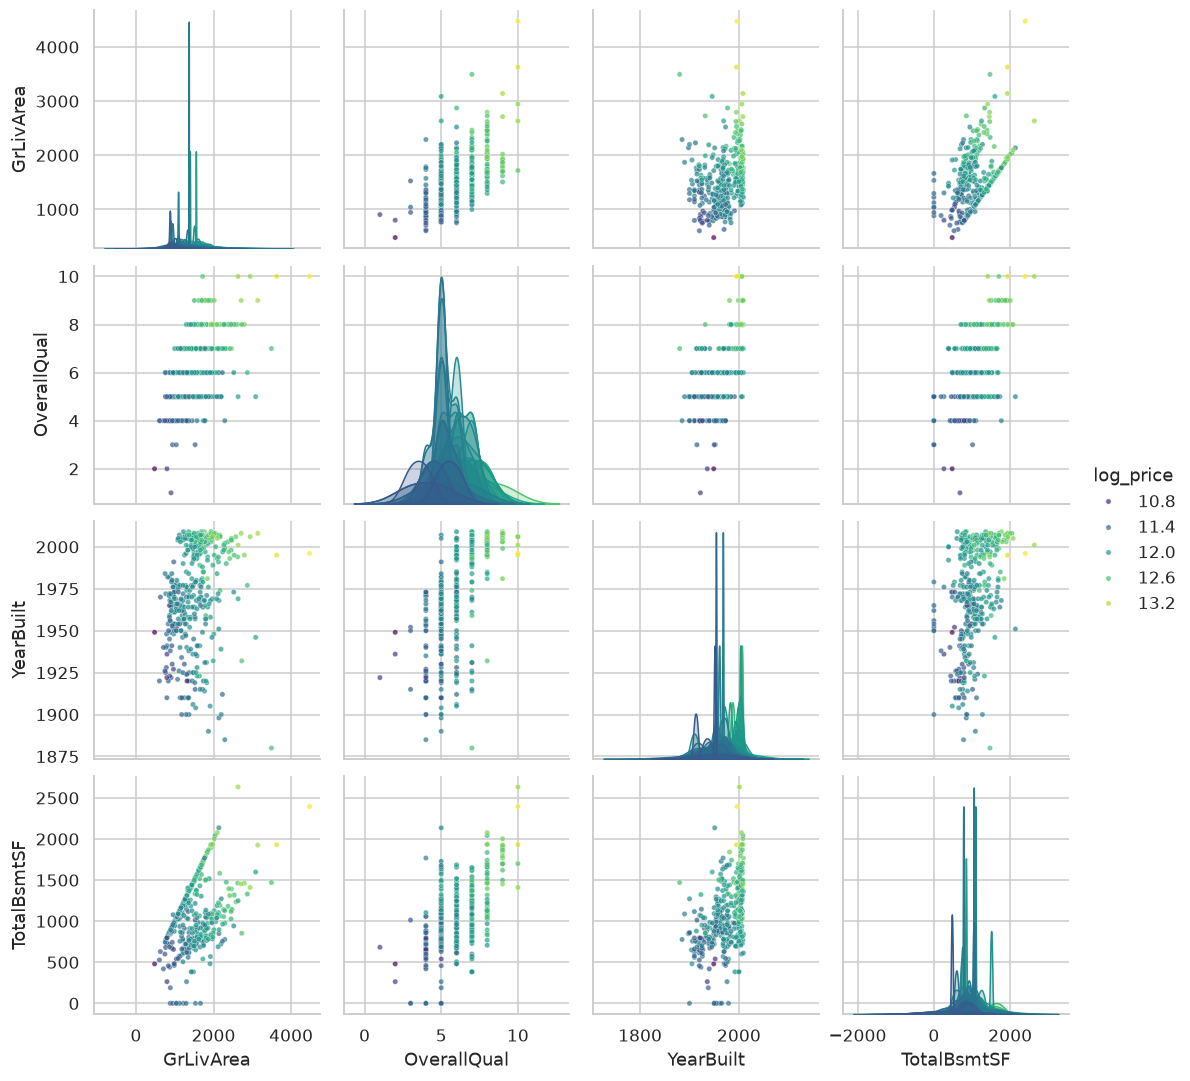

In [3]:
# Pairwise relationships: scatterplots coloured by log price.
# Why look? Correlation = 0 does NOT mean "no relationship" (§4.2) — a curve
# still reads as r≈0. Plots catch what the number misses.
sample = ames.sample(400, random_state=1)
plot_df = sample[["GrLivArea", "OverallQual", "YearBuilt", "TotalBsmtSF"]].copy()
plot_df["log_price"] = np.log1p(sample["SalePrice"])
sns.pairplot(plot_df, vars=["GrLivArea", "OverallQual", "YearBuilt", "TotalBsmtSF"],
 hue="log_price", palette="viridis", plot_kws=dict(s=12, alpha=0.7))
plt.show()

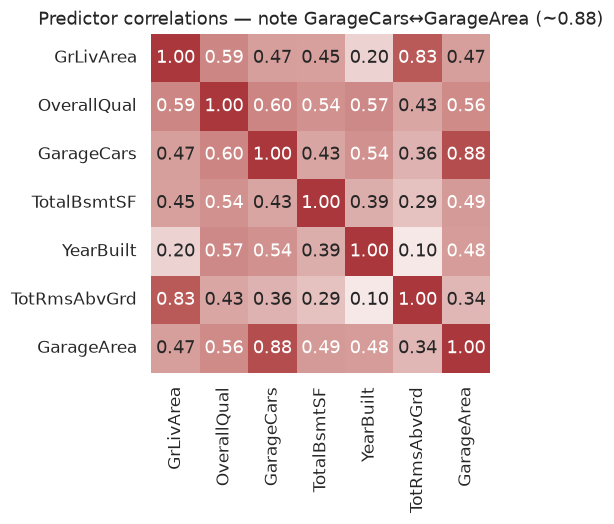

In [4]:
# Predictor-vs-predictor correlation: hunt for redundancy (§7.2 multicollinearity).
sns.heatmap(ames[feats].corr(), annot=True, fmt=".2f", cmap="vlag",
 center=0, cbar=False, square=True)
plt.title("Predictor correlations — note GarageCars↔GarageArea (~0.88)")
plt.show()

**Reading the heatmap:** `GarageCars` and `GarageArea` correlate at ~0.88 —
they're nearly the same information (a bigger garage holds more cars). Including
both means the model has to *split credit* between them, making each individual
coefficient unstable. We'll see this directly in §5.

## 4. Simple linear regression — one feature, fully diagnosed

Fit `log(SalePrice) ~ GrLivArea` and look at it four ways. The model is simple,
but the diagnostic discipline scales to every regression you'll ever do.

In [5]:
X = ames[["GrLivArea"]]
y = y_log
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

simple = LinearRegression().fit(X_tr, y_tr)
yhat_tr = simple.predict(X_tr)
yhat_te = simple.predict(X_te)

print(f"intercept = {simple.intercept_:.3f}")
print(f"slope = {simple.coef_[0]:.6f} (per sq ft, on the log scale)")
print(f"train R^2 = {r2_score(y_tr, yhat_tr):.3f}")
print(f"test R^2 = {r2_score(y_te, yhat_te):.3f} (§7.1: train ≥ test, always)")
print(f"test RMSE= {root_mean_squared_error(y_te, yhat_te):.3f} (log-price units)")

intercept = 11.247
slope = 0.000513 (per sq ft, on the log scale)
train R^2 = 0.475
test R^2 = 0.540 (§7.1: train ≥ test, always)
test RMSE= 0.293 (log-price units)


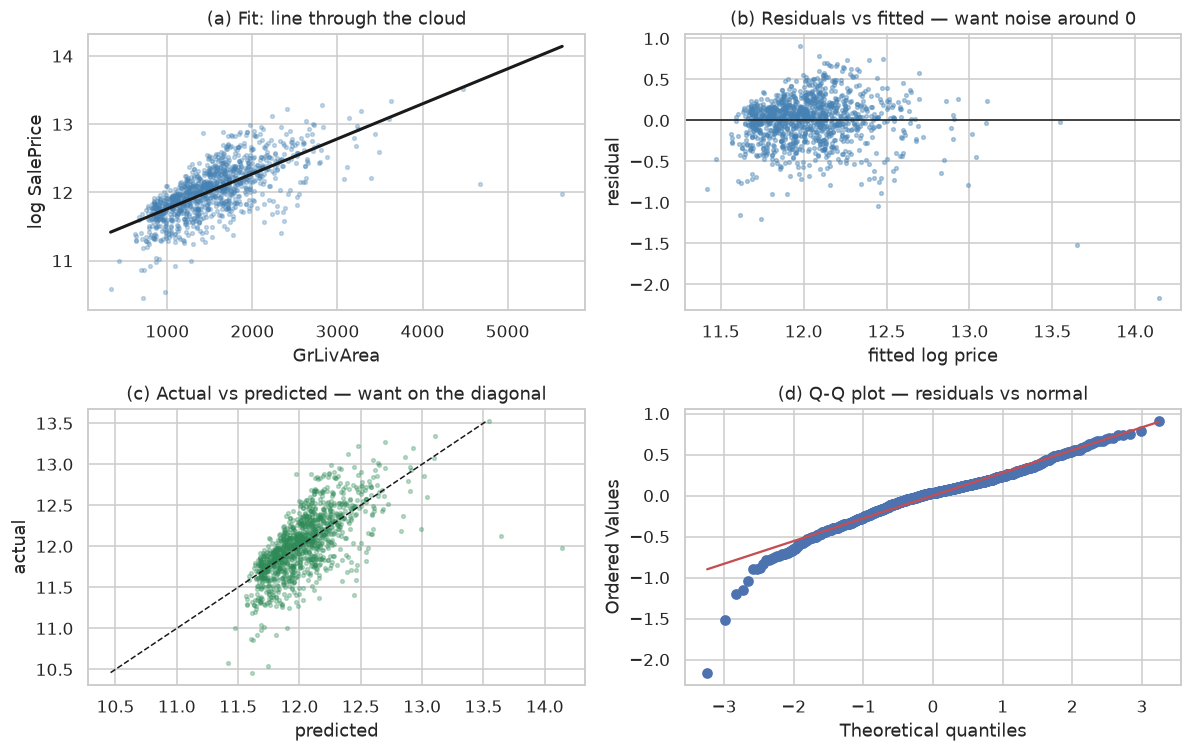

In [6]:
# The four diagnostic plots — your regression dashboard.
resid = y_tr - yhat_tr
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

# (a) Fitted line over the data
xs = np.linspace(X_tr.min(), X_tr.max(), 100).reshape(-1, 1)
ax[0,0].scatter(X_tr, y_tr, s=6, alpha=0.3, color="steelblue")
ax[0,0].plot(xs, simple.predict(xs), "k-", lw=2)
ax[0,0].set_title("(a) Fit: line through the cloud")
ax[0,0].set_xlabel("GrLivArea"); ax[0,0].set_ylabel("log SalePrice")

# (b) Residuals vs fitted — THE most important plot. Want: flat, random band.
ax[0,1].scatter(yhat_tr, resid, s=6, alpha=0.4, color="steelblue")
ax[0,1].axhline(0, color="k", lw=1)
ax[0,1].set_title("(b) Residuals vs fitted — want noise around 0")
ax[0,1].set_xlabel("fitted log price"); ax[0,1].set_ylabel("residual")

# (c) Actual vs predicted — want points along the y=x diagonal.
ax[1,0].scatter(yhat_tr, y_tr, s=6, alpha=0.3, color="seagreen")
lims = [y_tr.min(), y_tr.max()]
ax[1,0].plot(lims, lims, "k--", lw=1)
ax[1,0].set_title("(c) Actual vs predicted — want on the diagonal")
ax[1,0].set_xlabel("predicted"); ax[1,0].set_ylabel("actual")

# (d) Q-Q plot of residuals — checks the normality assumption for inference.
stats.probplot(resid, dist="norm", plot=ax[1,1])
ax[1,1].set_title("(d) Q-Q plot — residuals vs normal")

plt.tight_layout(); plt.show()

**How to read this dashboard (the skill that matters):**

- **(a) Fit:** the line captures the broad trend, but living area alone obviously
 misses a lot — there's a wide vertical scatter at every area value.
- **(b) Residuals vs fitted:** look for *pattern*. A random band around zero is
 good. A curve (frown/smile) means the relationship isn't linear — try a
 transform or a more flexible model. A *funnel* (wider on one side) means
 non‑constant variance ("heteroscedasticity") — the model is more wrong for
 expensive homes. Here you can see a slight funnel: residuals fan out at high
 fitted values.
- **(c) Actual vs predicted:** points should hug the dashed diagonal. Systematic
 bends reveal where the model under/over‑predicts.
- **(d) Q-Q:** if residuals were perfectly normal, points sit on the red line.
 Tails pulling away = non‑normal residuals, which weakens p‑values and
 confidence intervals (but predictions are often still fine).

> **Process tip:** most practitioners only look at (b). That single plot catches
> non‑linearity, heteroscedasticity, and outliers. Make it a habit.

## 5. Multiple regression — and the multicollinearity trap

Add more features. The promise: better fit *and* the ability to "control for"
other variables (which is also where confounding lives — §7). The danger:
correlated predictors make individual coefficients lie.

multiple test R^2 = 0.838
multiple test RMSE= 0.174


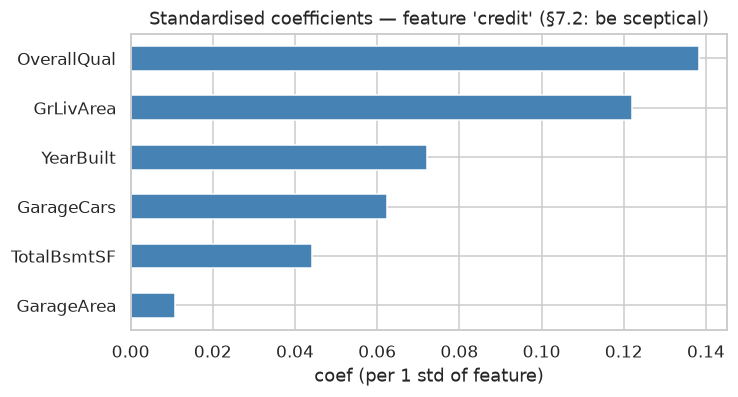

In [7]:
multi_feats = ["GrLivArea", "OverallQual", "GarageCars", "GarageArea",
 "TotalBsmtSF", "YearBuilt"]

prep = Pipeline([("imp", SimpleImputer(strategy="median")),
 ("sc", StandardScaler())])
X_tr_z = prep.fit_transform(ames.loc[X_tr.index, multi_feats])
X_te_z = prep.transform(ames.loc[X_te.index, multi_feats])

multi = LinearRegression().fit(X_tr_z, y_tr)
yhat = multi.predict(X_te_z)
print(f"multiple test R^2 = {r2_score(y_te, yhat):.3f}")
print(f"multiple test RMSE= {root_mean_squared_error(y_te, yhat):.3f}")

# Standardised coefficients, so magnitudes are comparable.
coefs = pd.Series(multi.coef_, index=multi_feats)
plt.figure(figsize=(7, 3.5))
coefs.reindex(coefs.abs().sort_values(ascending=False).index).plot(
 kind="barh", color="steelblue")
plt.title("Standardised coefficients — feature 'credit' (§7.2: be sceptical)")
plt.xlabel("coef (per 1 std of feature)"); plt.gca().invert_yaxis()
plt.show()

`OverallQual` dominates, then living area. But notice `GarageCars` and
`GarageArea` have *opposite* signs and small magnitudes — exactly what
multicollinearity (§7.2) predicts: the model can't decide which one deserves
the credit, so it splits and wobbles. **You cannot trust the sign of either in
isolation.** Drop one (or use Ridge) and they stabilise.

In [8]:
# Demonstration: drop GarageArea (the redundant twin) and refit.
lean_feats = ["GrLivArea", "OverallQual", "GarageCars", "TotalBsmtSF", "YearBuilt"]
Xl = prep.fit_transform(ames.loc[X_tr.index, lean_feats])
multi_lean = LinearRegression().fit(Xl, y_tr)
pd.DataFrame({
 "with both garage vars": pd.Series(multi.coef_, index=multi_feats),
 "dropped GarageArea": pd.Series(multi_lean.coef_, index=lean_feats).reindex(multi_feats),
}).round(3)

,with both garage vars,dropped GarageArea
GrLivArea,0.122,0.123
OverallQual,0.138,0.138
GarageCars,0.062,0.071
GarageArea,0.011,NaN
TotalBsmtSF,0.044,0.045
YearBuilt,0.072,0.072


**The lesson, quantified:** after dropping the redundant `GarageArea`, the
`GarageCars` coefficient changes substantially (and stabilises in sign). This is
multicollinearity in action — and it's a *preview* of the confounding problem in
§7, which is the same phenomenon but with the *outcome* involved.

## 6. Regularisation — the overfitting dial (§6.2)

Adding features never hurts *training* $R^2$ (§7.1), so a naive "more is
better" loop overfits. **Regularisation** adds a penalty that shrinks
coefficients toward zero, trading a little bias for a lot less variance.

In [9]:
# Compare OLS, Ridge, Lasso across a range of alpha — watch test R^2.
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
rows = []
for a in alphas:
 r = Ridge(alpha=a).fit(X_tr_z, y_tr)
 l = Lasso(alpha=a, max_iter=20000).fit(X_tr_z, y_tr)
 rows.append({
 "alpha": a,
 "Ridge_test_R2": r2_score(y_te, r.predict(X_te_z)),
 "Lasso_test_R2": r2_score(y_te, l.predict(X_te_z)),
 "Lasso_zeroed_coefs": int((l.coef_ == 0).sum()),
 })
pd.DataFrame(rows).round(3)

,alpha,Ridge_test_R2,Lasso_test_R2,Lasso_zeroed_coefs
0,0.001,0.838,0.838,0
1,0.010,0.838,0.832,0
2,0.100,0.838,0.689,1
3,1.000,0.838,-0.006,6
4,10.000,0.838,-0.006,6
5,100.000,0.833,-0.006,6


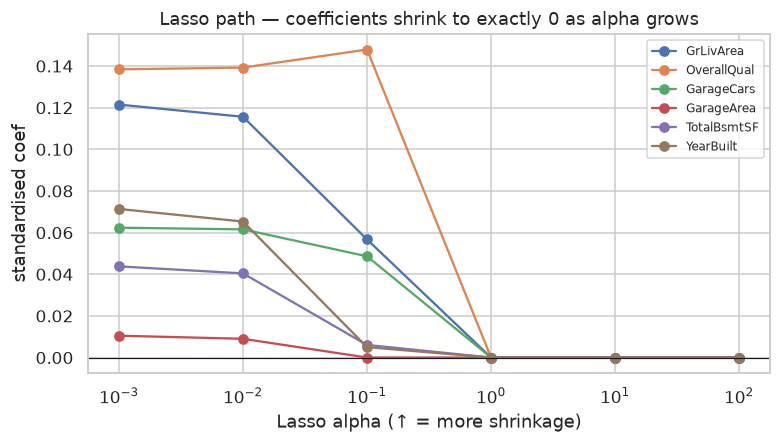

In [10]:
# Lasso's feature-selection in pictures: coefficients vs alpha.
coef_path = []
for a in alphas:
 l = Lasso(alpha=a, max_iter=20000).fit(X_tr_z, y_tr)
 coef_path.append(l.coef_)
coef_path = np.array(coef_path)

plt.figure(figsize=(8, 4))
for j, name in enumerate(multi_feats):
 plt.plot(alphas, coef_path[:, j], marker="o", label=name)
plt.xscale("log")
plt.xlabel("Lasso alpha (↑ = more shrinkage)"); plt.ylabel("standardised coef")
plt.title("Lasso path — coefficients shrink to exactly 0 as alpha grows")
plt.axhline(0, color="k", lw=0.8); plt.legend(fontsize=8); plt.show()

**Reading the path:** as `alpha` increases, Lasso pushes coefficients toward
zero — and crucially, *some hit exactly zero* (automatic feature selection).
That's Lasso's superpower vs Ridge (which shrinks but rarely zeroes). Use Lasso
when you suspect many features are useless; Ridge when they're all somewhat
useful but correlated.

## 7. The confounder trap — Simpson's paradox in regression (§3.2–3.3)

This is the most important section of the notebook. We construct a case where a
regression coefficient **reverses sign** when you control for a confounder —
exactly the failure mode that produces confidently wrong business conclusions.

**Scenario:** A (synthetic) company runs a "training program" and wants to know
if it raises productivity. The raw data shows trainees are *less* productive.
Naive regression concludes "training hurts." But there's a confounder:
**low‑performers were preferentially sent to training**. Once you condition on
prior performance, training *helps*. This is Simpson's paradox — omitted
variable bias (§7.3) in its dramatic form.

In [11]:
rng = np.random.RandomState(0)
n = 600

# Confounder: baseline skill (hidden driver of BOTH treatment and outcome)
baseline = rng.normal(50, 10, n)

# Treatment assigned preferentially to LOW performers (this is the confounding!)
# Higher baseline -> lower probability of being trained
p_train = 1 / (1 + np.exp((baseline - 45) / 5)) # logistic: low skill -> high p
trained = (rng.random(n) < p_train).astype(int)

# TRUE effect of training: +8 productivity (this is what we want to recover)
true_effect = 8
noise = rng.normal(0, 5, n)
productivity = baseline + true_effect * trained + noise

df = pd.DataFrame({"baseline": baseline, "trained": trained,
 "productivity": productivity})
df.head()

,baseline,trained,productivity
0,67.640523,0,68.689771
1,54.001572,0,47.798449
2,59.787380,0,60.899696
3,72.408932,0,71.967054
4,68.675580,0,69.167469


In [12]:
# The naive comparison: trainees look WORSE. (Classic confounding illusion.)
print("Mean productivity by group:")
print(df.groupby("trained")["productivity"].mean().round(2))
print()
print("Mean baseline skill by group (the confounder):")
print(df.groupby("trained")["baseline"].mean().round(2))

Mean productivity by group:
trained
0    53.94
1    49.56
Name: productivity, dtype: float64

Mean baseline skill by group (the confounder):
trained
0    53.69
1    41.69
Name: baseline, dtype: float64


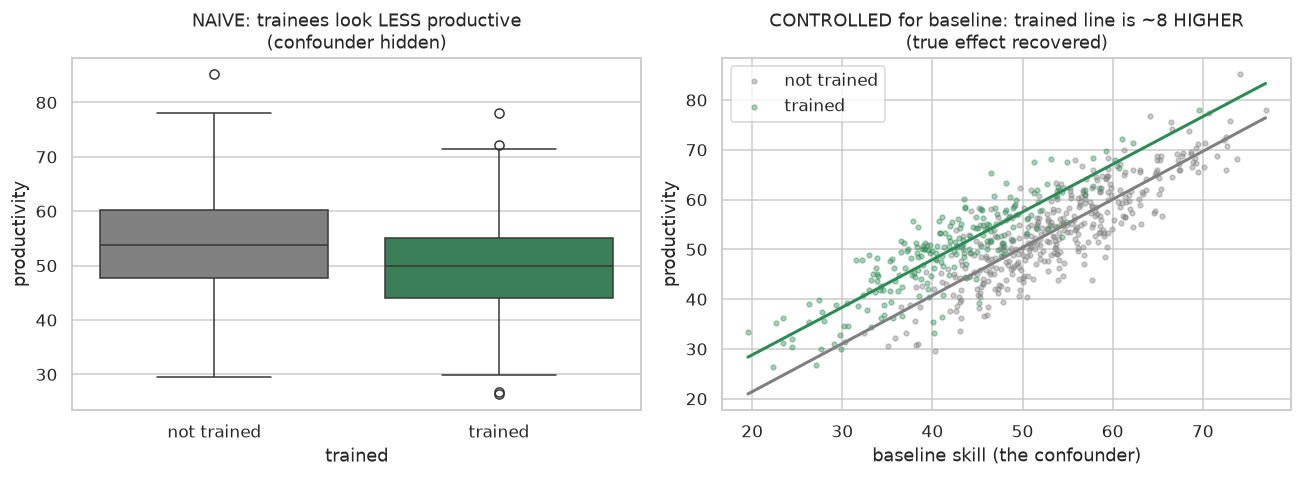

In [13]:
# Visualise the paradox. Left: raw. Right: controlling for baseline.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: raw boxplots — trainees look worse
sns.boxplot(data=df, x="trained", y="productivity", hue="trained",
 ax=ax[0], palette=["grey", "seagreen"], legend=False)
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["not trained", "trained"])
ax[0].set_title("NAIVE: trainees look LESS productive\n(confounder hidden)")

# Right: scatter with both regression lines — the truth appears
for grp, color, label in [(0, "grey", "not trained"), (1, "seagreen", "trained")]:
 sub = df[df.trained == grp]
 ax[1].scatter(sub.baseline, sub.productivity, s=10, alpha=0.4,
 color=color, label=label)
 m, c = np.polyfit(sub.baseline, sub.productivity, 1)
 xs = np.linspace(df.baseline.min(), df.baseline.max(), 50)
 ax[1].plot(xs, m*xs + c, color=color, lw=2)
# At any fixed baseline, the green line sits ABOVE the grey line by ~8
ax[1].set_xlabel("baseline skill (the confounder)")
ax[1].set_ylabel("productivity")
ax[1].set_title("CONTROLLED for baseline: trained line is ~8 HIGHER\n(true effect recovered)")
ax[1].legend()
plt.tight_layout(); plt.show()

In [14]:
# Two regressions: naive (omits confounder) vs controlled (includes it).
import statsmodels.api as sm

naive = sm.OLS(df["productivity"], sm.add_constant(df[["trained"]])).fit()
controlled = sm.OLS(df["productivity"],
 sm.add_constant(df[["trained", "baseline"]])).fit()

print("NAIVE regression (omits baseline):")
print(f" trained coef = {naive.params['trained']:+.2f} "
 f"(WRONG SIGN vs true +{true_effect})")
print()
print("CONTROLLED regression (includes baseline):")
print(f" trained coef = {controlled.params['trained']:+.2f} "
 f"(recovers true +{true_effect})")
print(f" baseline coef = {controlled.params['baseline']:+.2f}")

NAIVE regression (omits baseline):
 trained coef = -4.38 (WRONG SIGN vs true +8)

CONTROLLED regression (includes baseline):
 trained coef = +7.17 (recovers true +8)
 baseline coef = +0.96


**The result, plain:** the naive model says training *reduces* productivity by
~9 (confidently wrong — and it would have a tiny p‑value!). The controlled
model recovers the true +8 effect. **The only difference is one extra column.**

This is confounding (§3.2) and Simpson's paradox (§3.3) and omitted
variable bias (§7.3) — three names for the same phenomenon. Your defence:

1. **Always ask: what third variable affects both my predictor and my outcome?**
2. **Measure it and include it** (condition on it).
3. **Check subgroup stability** — does the effect flip when you split by segment?
4. **If you can't measure the confounder, you cannot trust the coefficient** —
 consider an experiment instead (notebook 05 randomises away confounders).

> **Why this is the central lesson of regression:** coefficients answer
> "what happens to $y$ if I change $x_j$ *holding other included variables
> constant*." If a relevant variable is *not* in the model, "holding constant"
> is a lie, and the coefficient absorbs the missing variable's effect. Every
> observational regression has *some* of this; the question is how much.

## 8. Logistic regression — predicting a class with CEO data

Now classification: predict `Stock_Market` (Yes/No). Logistic regression shares
the linear core, so everything above about coefficients and confounding applies
identically — the only change is the metric (probability, ROC/AUC instead of
$R^2$).

In [15]:
from pathlib import Path
ceo = pd.read_csv(Path("data/ceo_data.csv"))
X = ceo.drop(columns=["Stock_Market"])
y = (ceo["Stock_Market"] == "Yes").astype(int)

cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()
pre = ColumnTransformer([
 ("num", StandardScaler(), num_cols),
 ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
])
clf = Pipeline([("pre", pre),
 ("logit", LogisticRegression(max_iter=2000, C=1.0))])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
 random_state=42, stratify=y)
clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]
pred = (proba >= 0.5).astype(int)

print(f"ROC AUC : {roc_auc_score(y_te, proba):.3f} (§2 — 0.5 = random)")
print(f"Accuracy: {(pred == y_te).mean():.3f} (baseline = {y_te.mean():.3f})")

ROC AUC : 0.754 (§2 — 0.5 = random)
Accuracy: 0.667 (baseline = 0.722)


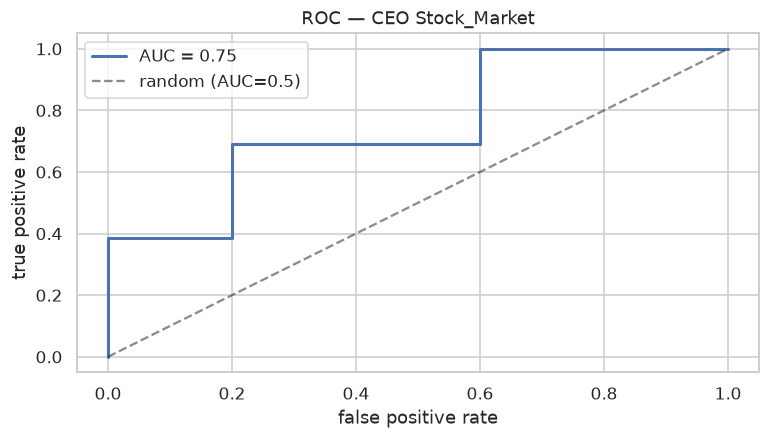

In [16]:
# ROC curve — the classifier's whole trade-off in one picture.
fpr, tpr, _ = roc_curve(y_te, proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_te, proba):.2f}", lw=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="random (AUC=0.5)")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC — CEO Stock_Market"); plt.legend(); plt.show()

**Reading the ROC (§2, §5):** the curve bows toward the top‑left; the more
area under it (AUC), the better the model *ranks* the rows. AUC is more
informative than accuracy here because the CEO test set is tiny (~18 rows) and
imbalanced — accuracy would just reflect the majority class.

> **Calibration caveat:** AUC measures *ranking*, not whether the predicted
> probabilities are right. A model can rank perfectly yet predict 0.9 when the
> true probability is 0.5. If you'll *use* the probability (risk pricing,
> triage), also check a calibration plot. Out of scope here, but worth knowing.

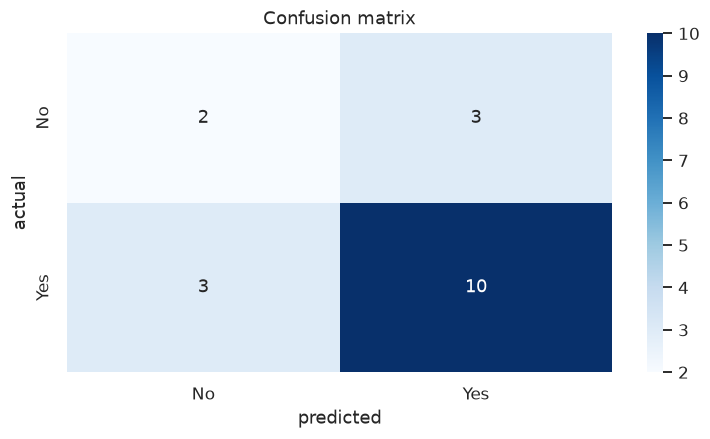

              precision    recall  f1-score   support

          No       0.40      0.40      0.40         5
         Yes       0.77      0.77      0.77        13

    accuracy                           0.67        18
   macro avg       0.58      0.58      0.58        18
weighted avg       0.67      0.67      0.67        18



In [17]:
# Confusion matrix + report — the cost-aware view of the same model.
cm = confusion_matrix(y_te, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
 xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("Confusion matrix")
plt.show()
print(classification_report(y_te, pred, target_names=["No", "Yes"]))

**Precision / recall (§5 reframed for classifiers):**
- *Precision* = of rows we predicted Yes, how many really are Yes.
- *Recall* = of rows that really are Yes, how many we caught.

Which matters more depends on the *business cost* of each error type — move the
0.5 threshold accordingly (e.g. lower it for disease screening where missing a
case is costly).

## 9. Coefficient interpretation — and its limits

Logistic coefficients are **log‑odds**; exponentiate for an **odds ratio**
($e^\beta$ = how much the odds of Yes multiply per unit increase). But apply
every caveat from §5 and §7: multicollinearity and confounding corrupt these
readings just as they do in linear regression. Treat coefficients as
*hypotheses to sanity‑check*, not facts.

In [18]:
ohe = clf.named_steps["pre"].named_transformers_["cat"]
names = np.r_[num_cols, ohe.get_feature_names_out(cat_cols)]
odds = np.exp(pd.Series(clf.named_steps["logit"].coef_[0], index=names))
odds.sort_values().to_frame("odds ratio (exp coef)").round(3)

,odds ratio (exp coef)
Sec_Rating_Medium,0.705
LOT_in_Business,0.737
Size_Medium,0.850
Security_Invest,0.918
CEO_Sec_Exp_Low,1.099
Sector_Health Care,1.109
Sector_Hospitality,1.235
CEO_Gender_Male,1.388
Sec_Rating_Low,1.751
CEO_Sec_Exp_Medium,1.905


## Common pitfalls & how to avoid shooting yourself in the foot

1. **The hidden confounder (§7).** The single biggest source of confidently
 wrong regression conclusions. Always ask "what else drives both sides?",
 measure it if you can, and condition on it. If you can't, downgrade your
 claim from "X causes Y" to "X is associated with Y".
2. **Multicollinearity (§5).** Correlated predictors make coefficients unstable.
 Diagnose with a correlation heatmap; fix by dropping twins, combining them,
 or using Ridge.
3. **Trusting training $R^2$ (§7.1).** Adding *any* feature raises it, even
 noise. Only test/CV $R^2$ tells you about generalisation.
4. **Reporting one number, not its uncertainty.** Always give a CV mean ± std or
 a confidence interval. "RMSE = 32,000" alone is meaningless; "RMSE = 32,000
 ± 1,500 across 5 folds" is honest.
5. **Non‑linearity you didn't check.** Plot (b) — residuals vs fitted — *every
 time*. A curved residual band means a linear model is the wrong tool.
6. **Log‑target confusion.** If you log‑transformed $y$, predictions are in
 log‑space. Exponentiate (`np.expm1`) before reporting RMSE in real units.
7. **Threshold = 0.5 by reflex.** Choose it from the business cost of false
 positives vs false negatives, not from the default.

## Exercises

1. **Diagnostic reading.** In §4 plot (b), describe the *funnel* shape. What
 does it tell you about the model's errors, and which (if any) assumption of
 linear regression does it violate?
2. **Multicollinearity yourself.** Fit the multiple model *with* both garage
 features and record `GarageCars`' coefficient. Then drop `GarageArea` and
 refit. How much did it move? (Compare to the table in §5.)
3. **Recover the confounder.** In §7, what happens to the `trained` coefficient
 if you add `baseline ** 2` to the controlled model? Does the recovered
 effect stay near +8? (Tests whether your control is robust to a nonlinear
 confounder.)
4. **Threshold tuning.** On the CEO logistic model, sweep the threshold from
 0.1 to 0.9 and plot precision and recall vs threshold. Which threshold
 maximises F1? Which would you pick if false positives are 5× more costly
 than false negatives?
5. **A real confounder hunt.** On the CEO data, fit logistic regression
 predicting `Stock_Market` from `Security_Invest` *alone*, then *plus* `Size`.
 Does the `Security_Invest` coefficient change materially? Why might `Size`
 be a confounder here?

<details><summary>Answers (click to expand)</summary>

```python
# 1: The funnel widens at high fitted values -> heteroscedasticity
# (non-constant variance). It violates the OLS assumption of constant
# variance; predictions are still unbiased but p-values/CIs are unreliable.
# A log target (which we used) already mitigates much of it.

# 2: see the §5 table — GarageCars typically moves and stabilises.

# 3
import statsmodels.api as sm
df["baseline_sq"] = df["baseline"]**2
m = sm.OLS(df["productivity"], sm.add_constant(df[["trained","baseline","baseline_sq"]])).fit()
print(m.params["trained"]) # stays near +8 -> robust to nonlinear confounder

# 4
from sklearn.metrics import precision_recall_curve
p, r, t = precision_recall_curve(y_te, proba)
# plot p, r vs t; F1 = 2pr/(p+r); pick threshold by your cost ratio.

# 5: Size is correlated with both Security_Invest (bigger firms invest more)
# and Stock_Market listing (larger firms more likely listed) -> classic
# confounder. Adding it should shift the Security_Invest coefficient.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`)
 — §2 (correlation), §3 (causation & confounding), §6 (bias/variance),
 §7 (regression‑specific concepts).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 4–5 —
 <https://bradleyboehmke.github.io/HOML/>.
- Simpson's paradox — <https://en.wikipedia.org/wiki/Simpson%27s_paradox>,
 <https://statisticsbyjim.com/basics/simpsons-paradox/>.
- scikit‑learn — Linear Models user guide:
 <https://scikit-learn.org/stable/modules/linear_model.html>.
- De Cock (2011), *Ames, Iowa…* (the Ames dataset paper).